In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import joblib
import warnings
warnings.filterwarnings("ignore")

print("Imports OK")

Imports OK


In [3]:
df = pd.read_csv('../data/preprocessed/youtoxic_preprocessed.csv')

print(f"Shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().to_dict()}")
print(f"Balance: {df["IsToxic"].value_counts().to_dict()}")
print()
df.head(3)

Shape: (997, 2)
Nulls: {'text_clean': 0, 'IsToxic': 0}
Balance: {0: 538, 1: 459}



,text_clean,IsToxic
0,people would take step back make case anyone e...,0
1,law enforcement train shoot apprehend train sh...,1
2,reckon black life matter banner hold white cun...,1


In [6]:
X = df['text_clean']
y = df['IsToxic']

print(f'Total muestras: {len(X)}')
print(f'Clase 0 (no tóxico): {(y==0).sum()}')
print(f'Clase 1 (tóxico):    {(y==1).sum()}')

Total muestras: 997
Clase 0 (no tóxico): 538
Clase 1 (tóxico):    459


In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,   
        ngram_range=(1, 1),    
        sublinear_tf=True,     
        min_df=3,              
        max_df=0.90,           
    )),
    ('clf', LinearSVC(
        C=0.01,                 
        class_weight='balanced', 
        max_iter=2000,         
        random_state=42,
    ))
])

print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LinearSVC(C=0.01, class_weight='balanced', max_iter=2000,
                           random_state=42))])


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring=['f1', 'precision', 'recall'],
    return_train_score=True,  # necesario para calcular el gap train/test
    n_jobs=-1,
)

print('=== RESULTADOS CROSS-VALIDATION (5 folds) ===')
print()
print(f'Train F1:  {scores["train_f1"].mean():.4f} ± {scores["train_f1"].std():.4f}')
print(f'Test  F1:  {scores["test_f1"].mean():.4f} ± {scores["test_f1"].std():.4f}')
print()
gap = (scores["train_f1"].mean() - scores["test_f1"].mean()) * 100
print(f'Gap train/test: {gap:.2f} pp', end='  ')
print('✅ Sin overfitting' if gap < 5 else '❌ Overfitting — revisar')
print()
print(f'Precision: {scores["test_precision"].mean():.4f}')
print(f'Recall:    {scores["test_recall"].mean():.4f}')

=== RESULTADOS CROSS-VALIDATION (5 folds) ===

Train F1:  0.8745 ± 0.0079
Test  F1:  0.6929 ± 0.0263

Gap train/test: 18.16 pp  ❌ Overfitting — revisar

Precision: 0.7091
Recall:    0.6799


In [12]:
# Split estratificado para la evaluación final
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # mantiene la proporción 54/46 en train y test
    random_state=42
)

# Entrenar con todos los datos de train
pipeline.fit(X_train, y_train)

# Predicciones
y_pred_train = pipeline.predict(X_train)
y_pred_test  = pipeline.predict(X_test)

# Métricas
train_f1 = f1_score(y_train, y_pred_train)
test_f1  = f1_score(y_test,  y_pred_test)
gap_pp   = (train_f1 - test_f1) * 100

print('=== EVALUACIÓN FINAL ===')
print()
print(f'Train F1:  {train_f1:.4f}')
print(f'Test  F1:  {test_f1:.4f}')
print(f'Gap:       {gap_pp:.2f} pp', end='  ')
print('✅' if gap_pp < 5 else '❌ Revisar overfitting')
print()
print(classification_report(y_test, y_pred_test, target_names=['No tóxico', 'Tóxico']))

=== EVALUACIÓN FINAL ===

Train F1:  0.8801
Test  F1:  0.6818
Gap:       19.83 pp  ❌ Revisar overfitting

              precision    recall  f1-score   support

   No tóxico       0.72      0.78      0.75       108
      Tóxico       0.71      0.65      0.68        92

    accuracy                           0.72       200
   macro avg       0.72      0.71      0.72       200
weighted avg       0.72      0.72      0.72       200



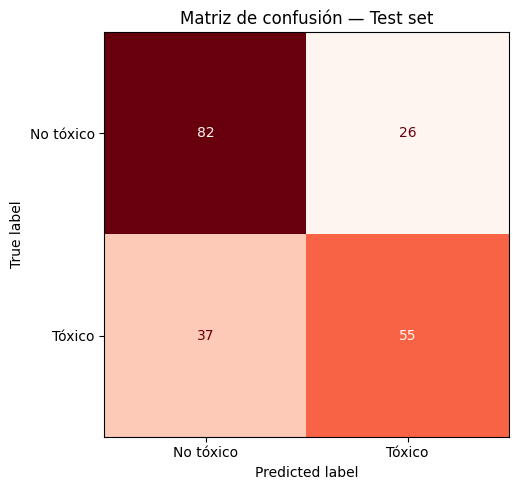

Verdaderos negativos (correctamente no tóxico): 82
Falsos positivos    (no tóxico predicho tóxico): 26
Falsos negativos    (tóxico predicho no tóxico): 37
Verdaderos positivos (correctamente tóxico):    55

De cada 100 tóxicos, el modelo detecta: 59.8


In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No tóxico', 'Tóxico']
)
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Matriz de confusión — Test set')

plt.tight_layout()
plt.savefig('../data/processed/model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretar los errores
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos negativos (correctamente no tóxico): {tn}')
print(f'Falsos positivos    (no tóxico predicho tóxico): {fp}')
print(f'Falsos negativos    (tóxico predicho no tóxico): {fn}')
print(f'Verdaderos positivos (correctamente tóxico):    {tp}')
print()
print(f'De cada 100 tóxicos, el modelo detecta: {tp/(tp+fn)*100:.1f}')